# Chapter 23 — Integers

> **Prerequisites:** ch022 (Natural Numbers), ch021 (History of Numbers)
> 
> **You will learn:**
> - How integers extend naturals by introducing additive inverses
> - Signed integer representation in computers (two's complement)
> - Integer division, floor division, and the division algorithm
> - Why integer overflow is a real danger and how Python handles it differently
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The integers extend the natural numbers by adding **additive inverses**: for every $n \in \mathbb{N}$, there exists $-n$ such that $n + (-n) = 0$. This makes $\mathbb{Z}$ closed under subtraction — the operation that $\mathbb{N}$ could not handle.

Integers are the mathematical home of:
- Signed quantities (debt, temperature below zero, altitude below sea level)
- The division algorithm (quotient and remainder)
- Modular arithmetic (the subject of ch031)
- Number theory (primes, GCDs, Diophantine equations)

**Critical distinction:** In Python, `int` is mathematically exact and arbitrarily large. In C, Java, and most compiled languages, `int` is a fixed-width binary type — it overflows. This difference has caused real-world bugs and security vulnerabilities.

**Common misconception:** "Integer division in Python works like in C." It does not. Python's `//` is floor division (rounds toward $-\infty$); C's `/` on integers truncates toward zero. They differ on negative numbers.

## 2. Intuition & Mental Models

**Think of ℤ as a signed number line:** ℕ is a ray from 0 rightward. ℤ extends that ray leftward to $-\infty$. The key new feature is symmetry around 0.

**Two's complement as a clock:** Computer hardware stores integers in fixed-width binary. A 4-bit two's complement register holds values $\{-8, -7, \ldots, 7\}$. Adding 1 to 7 gives -8 — it wraps around like a clock. *(This wrapping is modular arithmetic — see ch031.)*

**Division algorithm intuition:** $17 \div 5$ gives quotient 3 and remainder 2. Think of stacking 5-block towers from 17 blocks: you get 3 full towers with 2 left over.

*(Recall from ch022: natural numbers are closed under addition and multiplication but not subtraction. Integers restore that closure.)*

## 3. Visualization

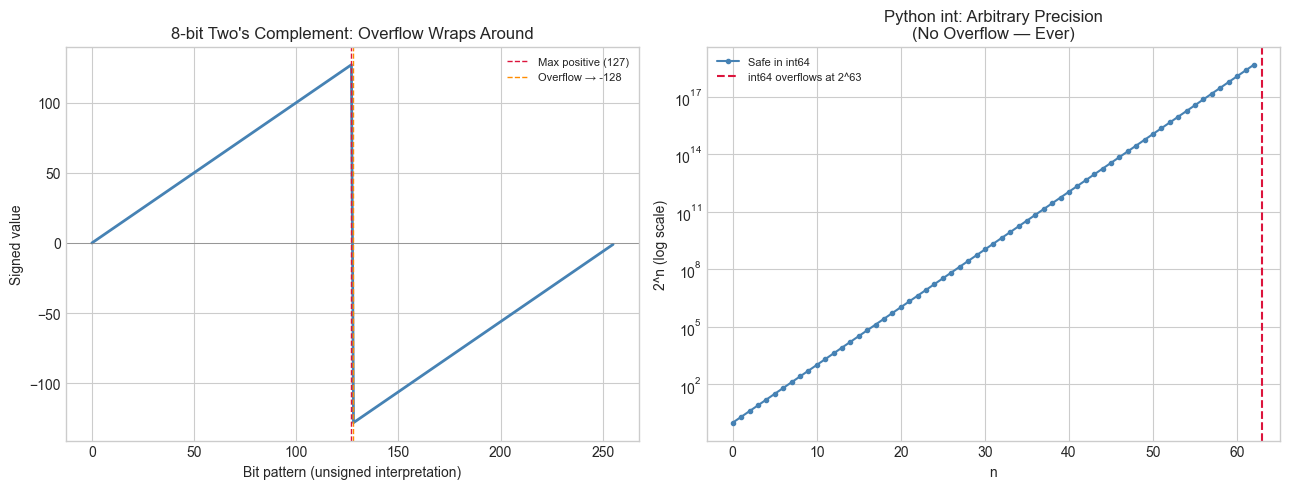

In [1]:
# --- Visualization: Two's complement overflow and Python's arbitrary integers ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Two's complement wrapping (8-bit signed: -128 to 127) ---
ax = axes[0]
BITS = 8
# Simulate 8-bit signed integers
vals = np.arange(0, 256, dtype=np.int32)
twos_comp = vals.copy()
twos_comp[twos_comp >= 128] -= 256  # map [128,255] to [-128,-1]

ax.plot(vals, twos_comp, color='steelblue', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(127, color='crimson', linestyle='--', linewidth=1, label='Max positive (127)')
ax.axvline(128, color='darkorange', linestyle='--', linewidth=1, label='Overflow → -128')
ax.set_xlabel('Bit pattern (unsigned interpretation)')
ax.set_ylabel('Signed value')
ax.set_title("8-bit Two's Complement: Overflow Wraps Around")
ax.legend(fontsize=8)

# --- Plot 2: Python's arbitrary-precision vs C-like int64 ---
ax = axes[1]
ns = range(0, 70)
python_vals = [2**n for n in ns]  # exact
int64_max = 2**63 - 1
# Simulate int64 overflow (just mark where it would overflow)
safe_ns = [n for n in ns if 2**n <= int64_max]
overflow_ns = [n for n in ns if 2**n > int64_max]

ax.semilogy(safe_ns, [2**n for n in safe_ns], 'o-', color='steelblue',
            label='Safe in int64', markersize=3)
if overflow_ns:
    ax.axvline(min(overflow_ns), color='crimson', linestyle='--', linewidth=1.5,
               label=f'int64 overflows at 2^{min(overflow_ns)}')
ax.set_xlabel('n')
ax.set_ylabel('2^n (log scale)')
ax.set_title('Python int: Arbitrary Precision\n(No Overflow — Ever)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Definition:** $\mathbb{Z} = \{\ldots, -3, -2, -1, 0, 1, 2, 3, \ldots\}$

**The Division Algorithm:** For any $a \in \mathbb{Z}$ and $b \in \mathbb{Z}$ with $b > 0$, there exist unique $q, r \in \mathbb{Z}$ such that:
$$a = q \cdot b + r, \quad 0 \leq r < b$$
- $q$ is the **quotient**: $q = \lfloor a/b \rfloor$
- $r$ is the **remainder**: $r = a \mod b$

**Example:** $a = -13, b = 5$:
- $\lfloor -13/5 \rfloor = \lfloor -2.6 \rfloor = -3$
- $r = -13 - (-3)(5) = -13 + 15 = 2$
- Check: $-13 = (-3)(5) + 2$ ✓

**Two's complement (n-bit):** Value of bit string $b_{n-1} b_{n-2} \ldots b_0$:
$$v = -b_{n-1} \cdot 2^{n-1} + \sum_{i=0}^{n-2} b_i \cdot 2^i$$

## 5. Python Implementation

In [2]:
# --- Implementation: Division algorithm, GCD, two's complement ---

def division_algorithm(a, b):
    """
    Compute quotient q and remainder r such that a = q*b + r, 0 <= r < b.

    Args:
        a: int (dividend)
        b: int (divisor, must be positive)

    Returns:
        (q, r): tuple of ints
    """
    assert b > 0, "Divisor must be positive"
    q = a // b   # Python floor division
    r = a % b    # Python modulo (always non-negative when b > 0)
    assert a == q * b + r, "Division algorithm invariant violated"
    return q, r


def gcd_euclidean(a, b):
    """
    Greatest common divisor via the Euclidean algorithm.
    Based on: gcd(a, b) = gcd(b, a mod b), with gcd(a, 0) = a.

    Args:
        a, b: non-negative ints

    Returns:
        int: gcd(a, b)
    """
    while b:
        a, b = b, a % b
    return a


def to_twos_complement(n, bits=8):
    """
    Return two's complement bit representation of integer n in `bits` bits.

    Args:
        n: int in range [-2^(bits-1), 2^(bits-1) - 1]
        bits: int, word width

    Returns:
        str: binary string of length `bits`
    """
    if n < 0:
        n = (1 << bits) + n  # add 2^bits to negative number
    return format(n, f'0{bits}b')


# Tests
import math

print("Division algorithm:")
for a, b in [(17, 5), (-13, 5), (0, 7), (100, 3)]:
    q, r = division_algorithm(a, b)
    print(f"  {a} = {q} × {b} + {r}")

print("\nGCD (Euclidean):")
for a, b in [(48, 18), (100, 75), (17, 13), (2024, 1984)]:
    g = gcd_euclidean(a, b)
    assert g == math.gcd(a, b)
    print(f"  gcd({a}, {b}) = {g}  ✓")

print("\nTwo's complement (8-bit):")
for n in [0, 1, 127, -1, -128, -13]:
    print(f"  {n:5d} → {to_twos_complement(n)}")

print("\nPython arbitrary precision:")
big = 2 ** 1000
print(f"  2^1000 has {len(str(big))} decimal digits")

Division algorithm:
  17 = 3 × 5 + 2
  -13 = -3 × 5 + 2
  0 = 0 × 7 + 0
  100 = 33 × 3 + 1

GCD (Euclidean):
  gcd(48, 18) = 6  ✓
  gcd(100, 75) = 25  ✓
  gcd(17, 13) = 1  ✓
  gcd(2024, 1984) = 8  ✓

Two's complement (8-bit):
      0 → 00000000
      1 → 00000001
    127 → 01111111
     -1 → 11111111
   -128 → 10000000
    -13 → 11110011

Python arbitrary precision:
  2^1000 has 302 decimal digits


## 6. Experiments

In [3]:
# --- Experiment 1: Python // vs C-style truncation for negative numbers ---
# Hypothesis: Python floor division and C truncation diverge exactly when a/b is negative
# Try changing: a and b

import math

print("Python // (floor division) vs C-style truncation:")
print(f"{'a':>6} {'b':>4}  {'Python a//b':>12}  {'C-style trunc(a/b)':>20}  {'Same?':>6}")
print('-' * 60)

test_pairs = [(7, 3), (-7, 3), (7, -3), (-7, -3),
              (10, 4), (-10, 4), (10, -4), (-10, -4)]

for a, b in test_pairs:
    python_result = a // b
    c_result = int(a / b)  # C-style truncation toward zero
    same = "✓" if python_result == c_result else "✗ DIFFER"
    print(f"{a:>6} {b:>4}  {python_result:>12}  {c_result:>20}  {same:>6}")

Python // (floor division) vs C-style truncation:
     a    b   Python a//b    C-style trunc(a/b)   Same?
------------------------------------------------------------
     7    3             2                     2       ✓
    -7    3            -3                    -2  ✗ DIFFER
     7   -3            -3                    -2  ✗ DIFFER
    -7   -3             2                     2       ✓
    10    4             2                     2       ✓
   -10    4            -3                    -2  ✗ DIFFER
    10   -4            -3                    -2  ✗ DIFFER
   -10   -4             2                     2       ✓


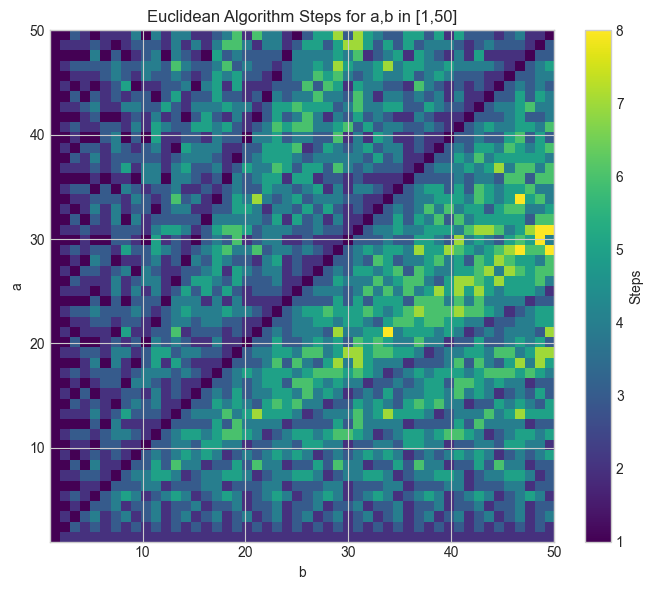

In [4]:
# --- Experiment 2: Euclidean algorithm step count ---
# Hypothesis: inputs near consecutive Fibonacci numbers require the most steps
# Try changing: N (search space)
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N = 50  # <-- modify this

def gcd_steps(a, b):
    """Count steps in Euclidean algorithm."""
    steps = 0
    while b:
        a, b = b, a % b
        steps += 1
    return steps

# Build heatmap of step counts
counts = np.zeros((N, N), dtype=int)
for a in range(1, N + 1):
    for b in range(1, N + 1):
        counts[a-1, b-1] = gcd_steps(a, b)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(counts, origin='lower', cmap='viridis',
               extent=[1, N, 1, N], aspect='auto')
plt.colorbar(im, ax=ax, label='Steps')
ax.set_xlabel('b')
ax.set_ylabel('a')
ax.set_title(f'Euclidean Algorithm Steps for a,b in [1,{N}]')
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** Compute `-17 // 5` and `-17 % 5` in Python, then verify the division algorithm identity: `-17 = q*5 + r`. *(Expected: q=-4, r=3)*

**Easy 2.** Write a function `sign(n)` that returns -1, 0, or 1 using only integer arithmetic (no conditionals, if possible). *(Hint: think about `-n // (abs(n) + 1)`)*

**Medium 1.** The Extended Euclidean Algorithm finds integers $x, y$ such that $ax + by = \gcd(a,b)$. Implement it. Test with $a=35, b=15$ (should give gcd=5).

**Medium 2.** Explain and demonstrate why numpy's integer arrays overflow while Python's `int` does not. Write code that creates a numpy int8 array, adds to it until it overflows, and plots the wrapped values.

**Hard.** The Ariane 5 rocket exploded in 1996 due to an integer overflow (a 64-bit float was converted to a 16-bit integer). Simulate this failure: generate a float that fits in float64 but overflows int16, and demonstrate what a real system might compute incorrectly. Write a safe conversion function that raises an error instead of overflowing.

## 8. Mini Project

In [5]:
# --- Mini Project: RSA Key Generation (Simplified) ---
# Problem: RSA encryption's security rests entirely on integer arithmetic.
#          Even a toy version requires GCD, modular inverse, and prime testing.
# Task: Implement mini-RSA with small primes and encrypt/decrypt a message.

def is_prime(n):
    """Trial-division primality test."""
    if n < 2: return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0: return False
    return True

def mod_inverse(e, phi):
    """
    Compute the modular inverse of e mod phi (i.e., d such that e*d ≡ 1 mod phi).
    Uses extended Euclidean algorithm.

    Args:
        e: int
        phi: int

    Returns:
        int: d such that (e * d) % phi == 1
    """
    # TODO: implement using extended Euclidean algorithm
    pass

# Choose small primes
p, q = 61, 53  # In real RSA, these would be 2048-bit primes
assert is_prime(p) and is_prime(q)

n = p * q                    # modulus
phi = (p - 1) * (q - 1)      # Euler's totient
e = 17                        # public exponent (must be coprime to phi)

d = mod_inverse(e, phi)

if d is not None:
    # Encrypt: c = m^e mod n
    # Decrypt: m = c^d mod n
    message = 42
    ciphertext = pow(message, e, n)
    decrypted = pow(ciphertext, d, n)

    print(f"p={p}, q={q}, n={n}, φ(n)={phi}")
    print(f"Public key:  (e={e}, n={n})")
    print(f"Private key: (d={d}, n={n})")
    print(f"Message:     {message}")
    print(f"Ciphertext:  {ciphertext}")
    print(f"Decrypted:   {decrypted}")
    print(f"Round-trip:  {'✓' if decrypted == message else '✗'}")

## 9. Chapter Summary & Connections

- Integers extend ℕ with additive inverses, closing the set under subtraction.
- The division algorithm guarantees unique quotient and remainder for any integer division — this is the foundation of all modular arithmetic.
- Python's `int` is arbitrary-precision; numpy and C integers are fixed-width and overflow. The difference matters in every numerical application.
- The Euclidean algorithm computes GCDs in $O(\log \min(a,b))$ steps — one of the oldest non-trivial algorithms.

**Forward connections:**
- The division algorithm is the basis of ch031 (Modular Arithmetic) — `a mod b` is exactly the remainder $r$.
- GCD and modular inverse are the core of RSA encryption, previewed here and revisited computationally in ch033 (Applications of Modulo in Programming).
- Two's complement overflow directly causes the floating-point issues examined in ch037 (Precision and Floating Point Errors).

**Backward connection:**
- The Peano successor function from ch022 implicitly defines addition; the division algorithm is a derived property of that construction.

**Going deeper:** The Extended Euclidean Algorithm and Bezout's identity underpin all of modern public-key cryptography. Chapter 5 of "Introduction to Algorithms" (CLRS) covers integer algorithms rigorously.